**Week 1 Jupyter Notebook – Linear Regression 1**

**Integrated Capstone Project**: Systemic Banking Risk Assessment

**Objective**

The purpose of this notebook is to explore linear regression techniques and understand relationships between borrower characteristics and financial outcomes. Specifically, this analysis investigates how income, age, credit history, loan characteristics, and other borrower attributes relate to credit risk indicators.

In [46]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [47]:
# Load Data

credit_risk = pd.read_csv("credit_risk_dataset.csv")
credit_default = pd.read_csv("credit_card_default.csv")
credit_eligibility = pd.read_csv("Credit Card Eligibility Data.csv")

print(credit_risk.head())
print(credit_default.head())
print(credit_eligibility.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [48]:
# Examine Dataset Structure

# Dataset dimensions

print("Credit Risk Shape:", credit_risk.shape)
print("Credit Default Shape:", credit_default.shape)
print("Credit Eligibility Shape:", credit_eligibility.shape)

# Variable information

print("\nCredit Risk Info")
print(credit_risk.info())

print("\nCredit Default Info")
print(credit_default.info())

print("\nCredit Eligibility Info")
print(credit_eligibility.info())

Credit Risk Shape: (32581, 12)
Credit Default Shape: (30000, 25)
Credit Eligibility Shape: (9709, 20)

Credit Risk Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_lengt

In [49]:
# Check for Missing Values

print("\nMissing Values: Credit Risk")
print(credit_risk.isnull().sum())

print("\nMissing Values: Credit Default")
print(credit_default.isnull().sum())

print("\nMissing Values: Credit Eligibility")
print(credit_eligibility.isnull().sum())

# Handle Missing Values

# Numerical columns

for col in credit_risk.select_dtypes(include=np.number):
    credit_risk[col] = credit_risk[col].fillna(
        credit_risk[col].median()
    )

for col in credit_default.select_dtypes(include=np.number):
    credit_default[col] = credit_default[col].fillna(
        credit_default[col].median()
    )

for col in credit_eligibility.select_dtypes(include=np.number):
    credit_eligibility[col] = credit_eligibility[col].fillna(
        credit_eligibility[col].median()
    )

# Categorical columns

for col in credit_risk.select_dtypes(include='object'):
    credit_risk[col] = credit_risk[col].fillna(
        credit_risk[col].mode()[0]
    )

for col in credit_default.select_dtypes(include='object'):
    credit_default[col] = credit_default[col].fillna(
        credit_default[col].mode()[0]
    )

for col in credit_eligibility.select_dtypes(include='object'):
    credit_eligibility[col] = credit_eligibility[col].fillna(
        credit_eligibility[col].mode()[0]
    )


Missing Values: Credit Risk
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing Values: Credit Default
Unnamed: 0                      0
limit_bal                       0
sex                           150
education                     150
marriage                      150
age                           150
payment_status_sep              0
payment_status_aug              0
payment_status_jul              0
payment_status_jun              0
payment_status_may              0
payment_status_apr              0
bill_statement_sep              0
bill_statement_aug              0
bill_statement_jul            

**Interpretation**

Missing values can bias statistical analyses and predictive models. Median imputation is used for numerical variables because financial variables often contain extreme values.

In [50]:
# Check for Duplicate Records

print("Credit Risk Duplicates:",
      credit_risk.duplicated().sum())

print("Credit Default Duplicates:",
      credit_default.duplicated().sum())

print("Credit Eligibility Duplicates:",
      credit_eligibility.duplicated().sum())

# Remove Duplicates

credit_risk = credit_risk.drop_duplicates()

credit_default = credit_default.drop_duplicates()

credit_eligibility = credit_eligibility.drop_duplicates()

Credit Risk Duplicates: 165
Credit Default Duplicates: 0
Credit Eligibility Duplicates: 0


In [51]:
# Save Cleaned Datasets

# Verify dimensions after cleaning

print("Credit Risk Shape After Cleaning:",
      credit_risk.shape)

print("Credit Default Shape After Cleaning:",
      credit_default.shape)

print("Credit Eligibility Shape After Cleaning:",
      credit_eligibility.shape)

# Save cleaned datasets

credit_risk.to_csv(
    "credit_risk_cleaned.csv",
    index=False
)

credit_default.to_csv(
    "credit_card_default_cleaned.csv",
    index=False
)

credit_eligibility.to_csv(
    "credit_card_eligibility_cleaned.csv",
    index=False
)


Credit Risk Shape After Cleaning: (32416, 12)
Credit Default Shape After Cleaning: (30000, 25)
Credit Eligibility Shape After Cleaning: (9709, 20)


In [52]:
# Descriptive Statistics

print(credit_risk.describe())

print(credit_default.describe())

print(credit_eligibility.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32416.000000   3.241600e+04       32416.000000  32416.000000   
mean      27.747008   6.609164e+04           4.768880   9593.845632   
std        6.354100   6.201558e+04           4.090411   6322.730241   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.854200e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.921800e+04           7.000000  12250.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   32416.000000  32416.000000         32416.000000   
mean       11.014662      0.218688             0.170250   
std         3.083050      0.413363             0.106812   
min         5.420000      0.000000             0.000000   
25%         8.490000      0.000000             0.090000   
50%   

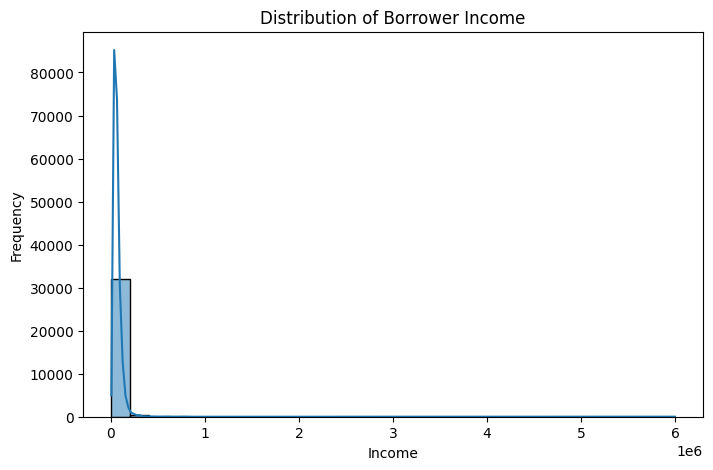

In [53]:
# Distribution of Borrower Income

plt.figure(figsize=(8,5))

sns.histplot(
    credit_risk['person_income'],
    bins=30,
    kde=True
)

plt.title("Distribution of Borrower Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

Income distributions in financial datasets are typically right-skewed because a small number of borrowers earn substantially higher incomes than the majority.

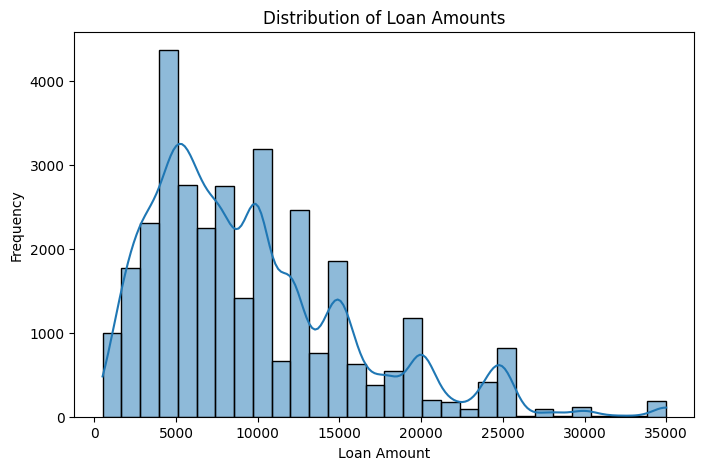

In [54]:
# Distribution of Loan Amounts

plt.figure(figsize=(8,5))

sns.histplot(
    credit_risk['loan_amnt'],
    bins=30,
    kde=True
)

plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

Most borrowers tend to receive loans within moderate ranges, while fewer borrowers receive very large loans.

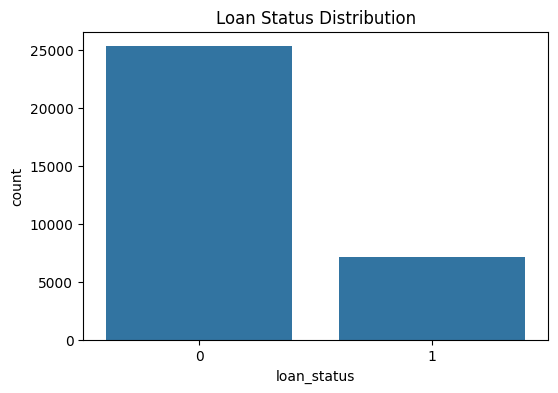

In [55]:
# Loan Status Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='loan_status',
    data=credit_risk
)

plt.title("Loan Status Distribution")
plt.show()

**Interpretation**

This visualization allows us to evaluate class balance between repayment and default outcomes.

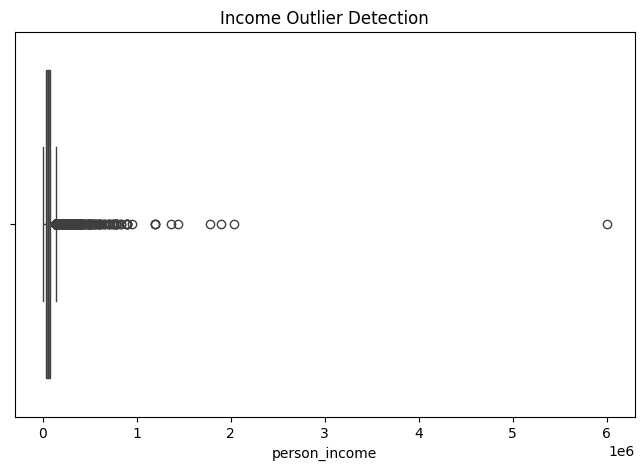

In [56]:
# Boxplot for Outlier Detection

plt.figure(figsize=(8,5))

sns.boxplot(
    x=credit_risk['person_income']
)

plt.title("Income Outlier Detection")
plt.show()

**Interpretation**

Outliers are common in financial data. Identifying them helps determine whether transformations or robust modeling approaches may be necessary.

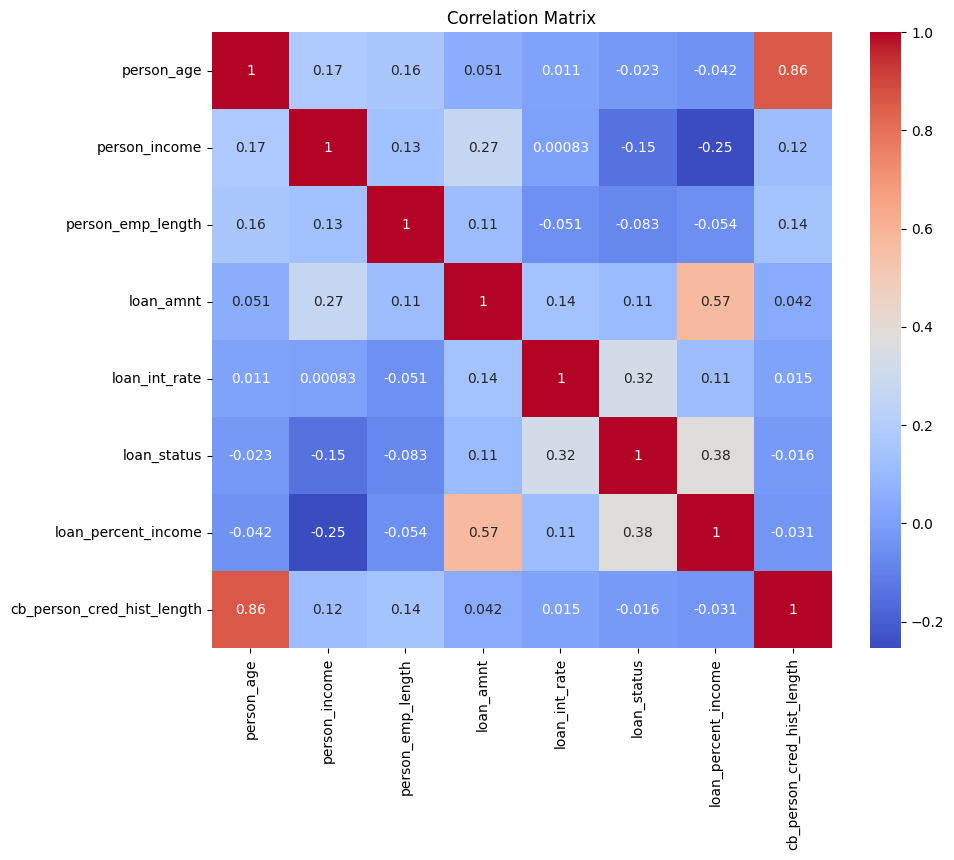

In [57]:
# Correlation Analysis

numeric_columns = credit_risk.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

**Interpretation**

Correlation analysis identifies variables that may be useful predictors in future regression and machine learning models.

EDA Conclusions

Several important observations emerged:



*   Income and loan amounts exhibit right-skewed distributions.

*   Some financial variables contain outliers.
*   Borrowers who default represent a smaller proportion of observations.


*   Several variables show moderate correlations that may influence credit risk.


*   Data cleaning improved the quality and reliability of the datasets.












**Linear Regression with Continuous Variables**

Research Question

Does borrower income predict loan amount?

Intercept: 7801.8126457873095
Slope: 0.02711436671288618
R²: 0.07072797892338611


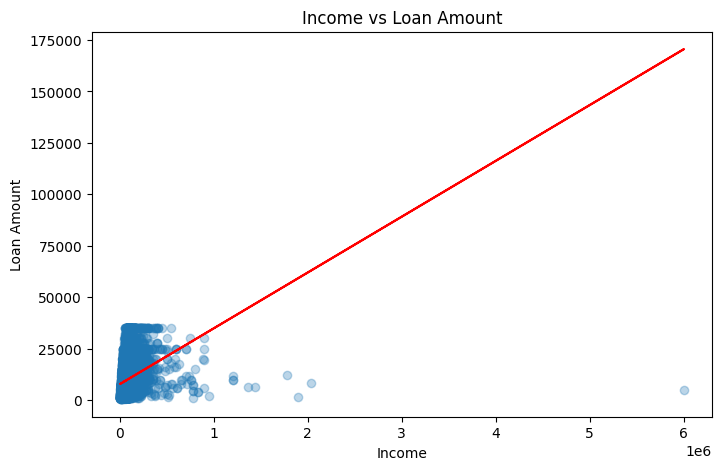

In [58]:
# Linear Regression with Continuous Variables

X = credit_risk[['person_income']]
y = credit_risk['loan_amnt']

model = LinearRegression()
model.fit(X,y)

predictions = model.predict(X)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R²:", r2_score(y,predictions))

# Visualization

plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.3)
plt.plot(X,predictions,color='red')
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

Polynomial R²: 0.11716079194462792


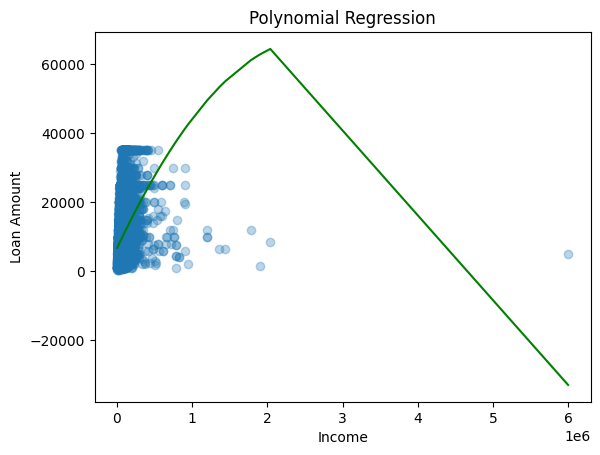

In [59]:
# Polynomial Regression

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly,y)

poly_predictions = poly_model.predict(X_poly)

print("Polynomial R²:", r2_score(y,poly_predictions))

# Visualization

sorted_zip = sorted(zip(X.values.flatten(), poly_predictions))

x_sorted, y_sorted = zip(*sorted_zip)

plt.scatter(X,y,alpha=0.3)
plt.plot(x_sorted,y_sorted,color='green')
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Polynomial Regression")
plt.show()

In [60]:
# Interaction Terms

# Research Question

# Do income and age jointly influence loan amount?

credit_risk['income_age_interaction'] = (
    credit_risk['person_income'] *
    credit_risk['person_age']
)

X = credit_risk[
    ['person_income',
     'person_age',
     'income_age_interaction']
]

X = sm.add_constant(X)

interaction_model = sm.OLS(
    credit_risk['loan_amnt'],
    X
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:              loan_amnt   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     1360.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:39:36   Log-Likelihood:            -3.2778e+05
No. Observations:               32416   AIC:                         6.556e+05
Df Residuals:                   32412   BIC:                         6.556e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   5797

In [61]:
# Categorical and Continuous Features
# Research Question

# Does home ownership status affect loan amount?


# Create dummies as integers
credit_risk_encoded = pd.get_dummies(
    credit_risk,
    columns=['person_home_ownership'],
    drop_first=True,
    dtype=int
)

features = [
    'person_income',
    'person_age',
    'person_home_ownership_OTHER',
    'person_home_ownership_OWN',
    'person_home_ownership_RENT'
]

# Build dataset
data = credit_risk_encoded[
    features + ['loan_amnt']
].copy()

# Force numeric conversion
for col in data.columns:
    data[col] = pd.to_numeric(
        data[col],
        errors='coerce'
    )

# Remove NaN and infinite values
data = data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

X = data[features].astype(float)
y = data['loan_amnt'].astype(float)

# Add constant
X = sm.add_constant(X)

# Fit model
cat_model = sm.OLS(y, X).fit()

print(cat_model.summary())

                            OLS Regression Results                            
Dep. Variable:              loan_amnt   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     541.7
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:39:36   Log-Likelihood:            -3.2840e+05
No. Observations:               32416   AIC:                         6.568e+05
Df Residuals:                   32410   BIC:                         6.569e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

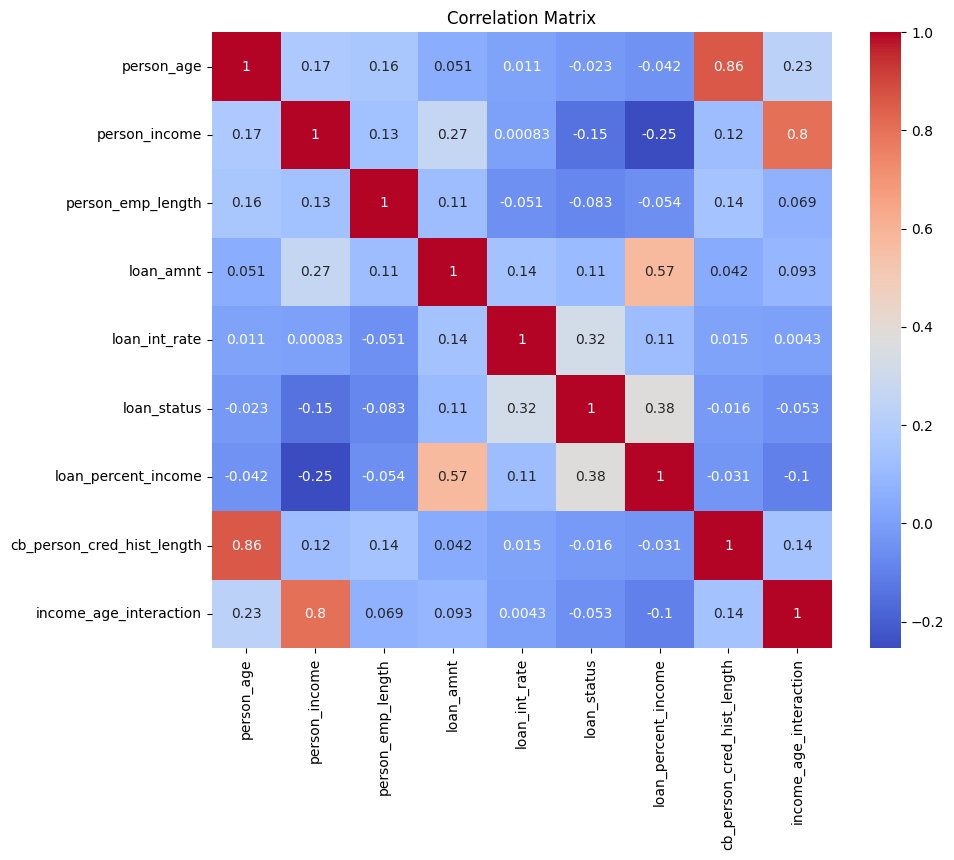

In [62]:
# Multicollinearity

# Correlation Matrix

numeric_vars = credit_risk.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_vars.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [63]:
# Variance Inflation Factor (VIF)

vif_data = credit_risk[
    ['person_income',
     'loan_amnt',
     'person_age',
     'cb_person_cred_hist_length']
].dropna()

vif_data = sm.add_constant(vif_data)

vif = pd.DataFrame()
vif["Variable"] = vif_data.columns

vif["VIF"] = [
    variance_inflation_factor(
        vif_data.values, i
    )
    for i in range(vif_data.shape[1])
]

print(vif)

                     Variable        VIF
0                       const  42.383374
1               person_income   1.111074
2                   loan_amnt   1.076331
3                  person_age   3.899592
4  cb_person_cred_hist_length   3.835922


**Conclusion**

The Week 1 analysis focused on exploring the relationships between borrower characteristics and loan amounts using exploratory data analysis, linear regression, polynomial regression, interaction terms, categorical variables, and multicollinearity diagnostics. After cleaning the datasets and examining their distributions, borrower income and loan amount were found to be right-skewed, indicating the presence of high-income borrowers and large loans.

The regression analysis showed that borrower income was the strongest predictor of loan amount, with higher-income individuals generally receiving larger loans. Home ownership status was also significant, as borrowers who rented or owned their homes outright tended to receive smaller loans than those with mortgages. In contrast, borrower age was not a statistically significant predictor of loan amount. The overall regression model was highly significant (F-statistic = 541.7, p < 0.001), indicating that the selected variables collectively explain a meaningful portion of the variation in loan amounts.

Multicollinearity diagnostics revealed that all VIF values were below 5, suggesting that the predictors do not exhibit serious multicollinearity and that the regression estimates are reliable. Although the condition number was large, this is likely due to differences in variable scales rather than problematic correlations among predictors.

Overall, the findings suggest that income and home ownership status are important factors in lending decisions, while age has a relatively limited effect. These results provide a strong foundation for future predictive modeling and credit risk analysis throughout the capstone project.







